# alphadia-validate
A notebook for exploring DIA hits for the sake of validation.

In [1]:
%reload_ext autoreload
%autoreload 2

In [ ]:
import pandas as pd
from pathlib import Path

pd.set_option("display.max_columns", None)
from src.slicer import SpectrumSlicer

from src.isoform_attention import isoform_attention_plot
from src.io import (
    load_diann_data,
    EXAMPLE_DIANN_REPORT_URL,
    EXAMPLE_DIANN_RAW_DATA_URL,
)
from src.mirror_plotting import mirror_w_xic_w_corrs

from IPython.display import Image

## 0. Set up data

In [ ]:
precursor_df, speclib_base, spectral_library_flat, dia_data = load_diann_data(
    download_urls=(EXAMPLE_DIANN_REPORT_URL, EXAMPLE_DIANN_RAW_DATA_URL),
    main_folder=Path("data") / "25_05_06_Phospho_SingleFile",
    model_device="cpu"
)

## 1. Select a precursor

In [4]:
precursor_df[["Phospho" in str(i) for i in precursor_df["mods"]]]

,raw_name,sequence,charge,rt,rt_start,rt_stop,mobility,proteins,uniprot_ids,genes,fdr,intensity,fdr1_search1,fdr2_search1,fdr1_search2,fdr2_search2,mods,mod_sites,nAA,rt_norm,precursor_mz,ccs,instrument,nce,mod_seq_hash,mod_seq_charge_hash,frag_start_idx,frag_stop_idx,flat_frag_start_idx,flat_frag_stop_idx
184,20250505_OA2_60SPD_MaOe_SA_O813_Bulk_B02_Phosp...,EGVLYVGSK,2,602.189392,597.056274,605.856567,0.0,SYUA_HUMAN,P37840;Q16143,SNCA,0.001696,72107320.0,0.002270,0.00149,0.0,0.0,Phospho@S,8,9,0.489123,516.244090,0.0,Orbitrap,25.0,13794088728286522885,13794088728286522887,1381,1389,2632,2654
1458,20250505_OA2_60SPD_MaOe_SA_O813_Bulk_B02_Phosp...,TVEGAGSIAAATGFVK,2,912.410767,910.073669,915.893372,0.0,SYUA_HUMAN,P37840,SNCA,0.000781,72107320.0,0.001567,0.00149,0.0,0.0,Phospho@T,1,16,0.741098,779.879271,0.0,Orbitrap,25.0,5519500652602416459,5519500652602416461,15545,15560,29292,29323
1461,20250505_OA2_60SPD_MaOe_SA_O813_Bulk_B02_Phosp...,TVEGAGSIAAATGFVK,2,865.430237,861.932556,868.918335,0.0,SYUA_HUMAN,P37840,SNCA,0.000781,72107320.0,0.002890,0.00149,0.0,0.0,Phospho@S,7,16,0.702939,779.879271,0.0,Orbitrap,25.0,17994920635628856072,17994920635628856074,15590,15605,29374,29414
1756,20250505_OA2_60SPD_MaOe_SA_O813_Bulk_B02_Phosp...,EQVTNVGGAVVTGVTAVAQK,3,961.613281,959.222412,965.149475,0.0,SYUA_HUMAN,P37840,SNCA,0.000781,72107320.0,0.002890,0.00149,0.0,0.0,Phospho@T,4,20,0.781063,670.008538,0.0,Orbitrap,25.0,17743180795282179642,17743180795282179645,20572,20591,37784,37819
2624,20250505_OA2_60SPD_MaOe_SA_O813_Bulk_B02_Phosp...,NEEGAPQEGILEDMPVDPDNEAYEMPSEEGYQDYEPEA,3,932.934998,929.416931,937.686157,0.0,SYUA_HUMAN,P37840,SNCA,0.000008,72107320.0,1.000000,1.00000,0.0,0.0,Oxidation@M;Phospho@Y;Phospho@S,14;23;27,38,0.757769,1488.225254,0.0,Orbitrap,25.0,11278990114538271878,11278990114538271881,42670,42707,67051,67070
2626,20250505_OA2_60SPD_MaOe_SA_O813_Bulk_B02_Phosp...,NEEGAPQEGILEDMPVDPDNEAYEMPSEEGYQDYEPEA,4,932.861511,929.338379,937.617737,0.0,SYUA_HUMAN,P37840,SNCA,0.000008,72107320.0,0.009981,0.00149,0.0,0.0,Oxidation@M;Oxidation@M;Phospho@S,14;25;27,38,0.757709,1100.427905,0.0,Orbitrap,25.0,998481289276488912,998481289276488916,42744,42781,67094,67114
2628,20250505_OA2_60SPD_MaOe_SA_O813_Bulk_B02_Phosp...,NEEGAPQEGILEDMPVDPDNEAYEMPSEEGYQDYEPEA,3,987.166077,982.472046,989.514771,0.0,SYUA_HUMAN,P37840,SNCA,0.000781,72107320.0,0.025485,0.00149,0.0,0.0,Phospho@Y;Oxidation@M;Phospho@S,23;25;27,38,0.801818,1488.225254,0.0,Orbitrap,25.0,11981981471463696298,11981981471463696301,42818,42855,67133,67150
2629,20250505_OA2_60SPD_MaOe_SA_O813_Bulk_B02_Phosp...,NEEGAPQEGILEDMPVDPDNEAYEMPSEEGYQDYEPEA,3,1091.478760,1087.903320,1096.198120,0.0,SYUA_HUMAN,P37840,SNCA,0.001696,72107320.0,1.000000,1.00000,0.0,0.0,Oxidation@Y;Oxidation@M;Phospho@S,23;25;27,38,0.886545,1466.901448,0.0,Orbitrap,25.0,18134817023947396106,18134817023947396109,42855,42892,67150,67168
2630,20250505_OA2_60SPD_MaOe_SA_O813_Bulk_B02_Phosp...,NEEGAPQEGILEDMPVDPDNEAYEMPSEEGYQDYEPEA,4,1091.409668,1087.825806,1096.119263,0.0,SYUA_HUMAN,P37840,SNCA,0.000008,72107320.0,1.000000,1.00000,0.0,0.0,Oxidation@Y;Oxidation@M;Phospho@S,23;25;27,38,0.886489,1100.427905,0.0,Orbitrap,25.0,18134817023947396106,18134817023947396110,42892,42929,67168,67190
2633,20250505_OA2_60SPD_MaOe_SA_O813_Bulk_B02_Phosp...,NEEGAPQEGILEDMPVDPDNEAYEMPSEEGYQDYEPEA,4,925.825989,922.312561,928.166687,0.0,SYUA_HUMAN,P37840,SNCA,0.006658,72107320.0,1.000000,1.00000,0.0,0.0,Phospho@S,27,38,0.751995,1092.430448,0.0,Orbitrap,25.0,5239135588431505815,5239135588431505819,43003,43040,67241,67266


In [5]:
# user input: select via position
selected_hash = precursor_df["mod_seq_charge_hash"].loc[1458]

# alternatively: select via sequence
# selected_hash = precursor_df[sequence == "SOME_SEQUENCE"]

# alternatively: use a random one from a certain percentile
# from src.small_helpers import get_random_precursor_hash
# selected_hash = get_random_precursor_hash(precursor_df, 0)

## 2. Preprocess

In [6]:
library_wrapper = SpectrumSlicer(spectral_library_flat, precursor_df, dia_data)

mz_library, intensity_library, spectrum_slice, fragment_library = (
    library_wrapper.get_by_hash(selected_hash)
)

Converting RT values to DIA cycle frame indices...


## 3. Plots

### Mirror plots


In [7]:
mirror_w_xic_w_corrs(
    spectrum_slice,
    mz_library,
    intensity_library,
    fragment_library,
    precursor_df,
    selected_hash,
    width=500,
    height=300,
)

alt.HConcatChart(...)

### Isoform attention plot

sequence     TVEGAGSIAAATGFVK
mods                Phospho@T
mod_sites                   1
Name: 1458, dtype: object


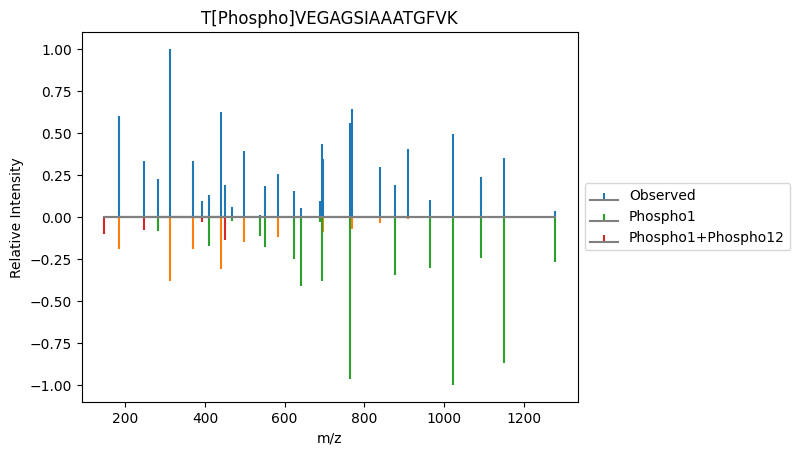

In [8]:
# in case you want to find some precursors with modifications:
# display(precursor_df[~pd.isna(precursor_df["mods"])][["mod_seq_charge_hash", "mods"]].head(10))

isoform_attention_plot(spectral_library_flat, precursor_df, dia_data, selected_hash)